<font size="5">Section 5: Structural Equation Modelling</font>

## Housekeeping and Data

<font size="3">**Tarea 3**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

In [60]:
#Primero exportamos las librerias que vamos a utilizar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
from stepmix.stepmix import StepMix


%matplotlib inline

Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

Leemos la base de datos, luego invertimos la variable "sk7" para que su denominación sea positiva, o sea, el uno sea lo mejor, además borramos los valores nulos y aquellos que tenían más de un padre o madre.

<class 'pandas.core.frame.DataFrame'>
Index: 29635 entries, 1 to 31054
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        29635 non-null  int64  
 1   edad        29635 non-null  int64  
 2   imce        29635 non-null  float64
 3   vive_padre  29635 non-null  int64  
 4   vive_madre  29635 non-null  int64  
 5   sk1         29635 non-null  int64  
 6   sk2         29635 non-null  int64  
 7   sk3         29635 non-null  int64  
 8   sk4         29635 non-null  int64  
 9   sk5         29635 non-null  int64  
 10  sk6         29635 non-null  int64  
 11  sk7         29635 non-null  int64  
 12  sk8         29635 non-null  int64  
 13  sk9         29635 non-null  int64  
 14  sk10        29635 non-null  int64  
 15  sk11        29635 non-null  int64  
 16  sk12        29635 non-null  int64  
 17  sk13        29635 non-null  int64  
 18  act_fisica  29635 non-null  float64
 19  area        29635 non-null  in

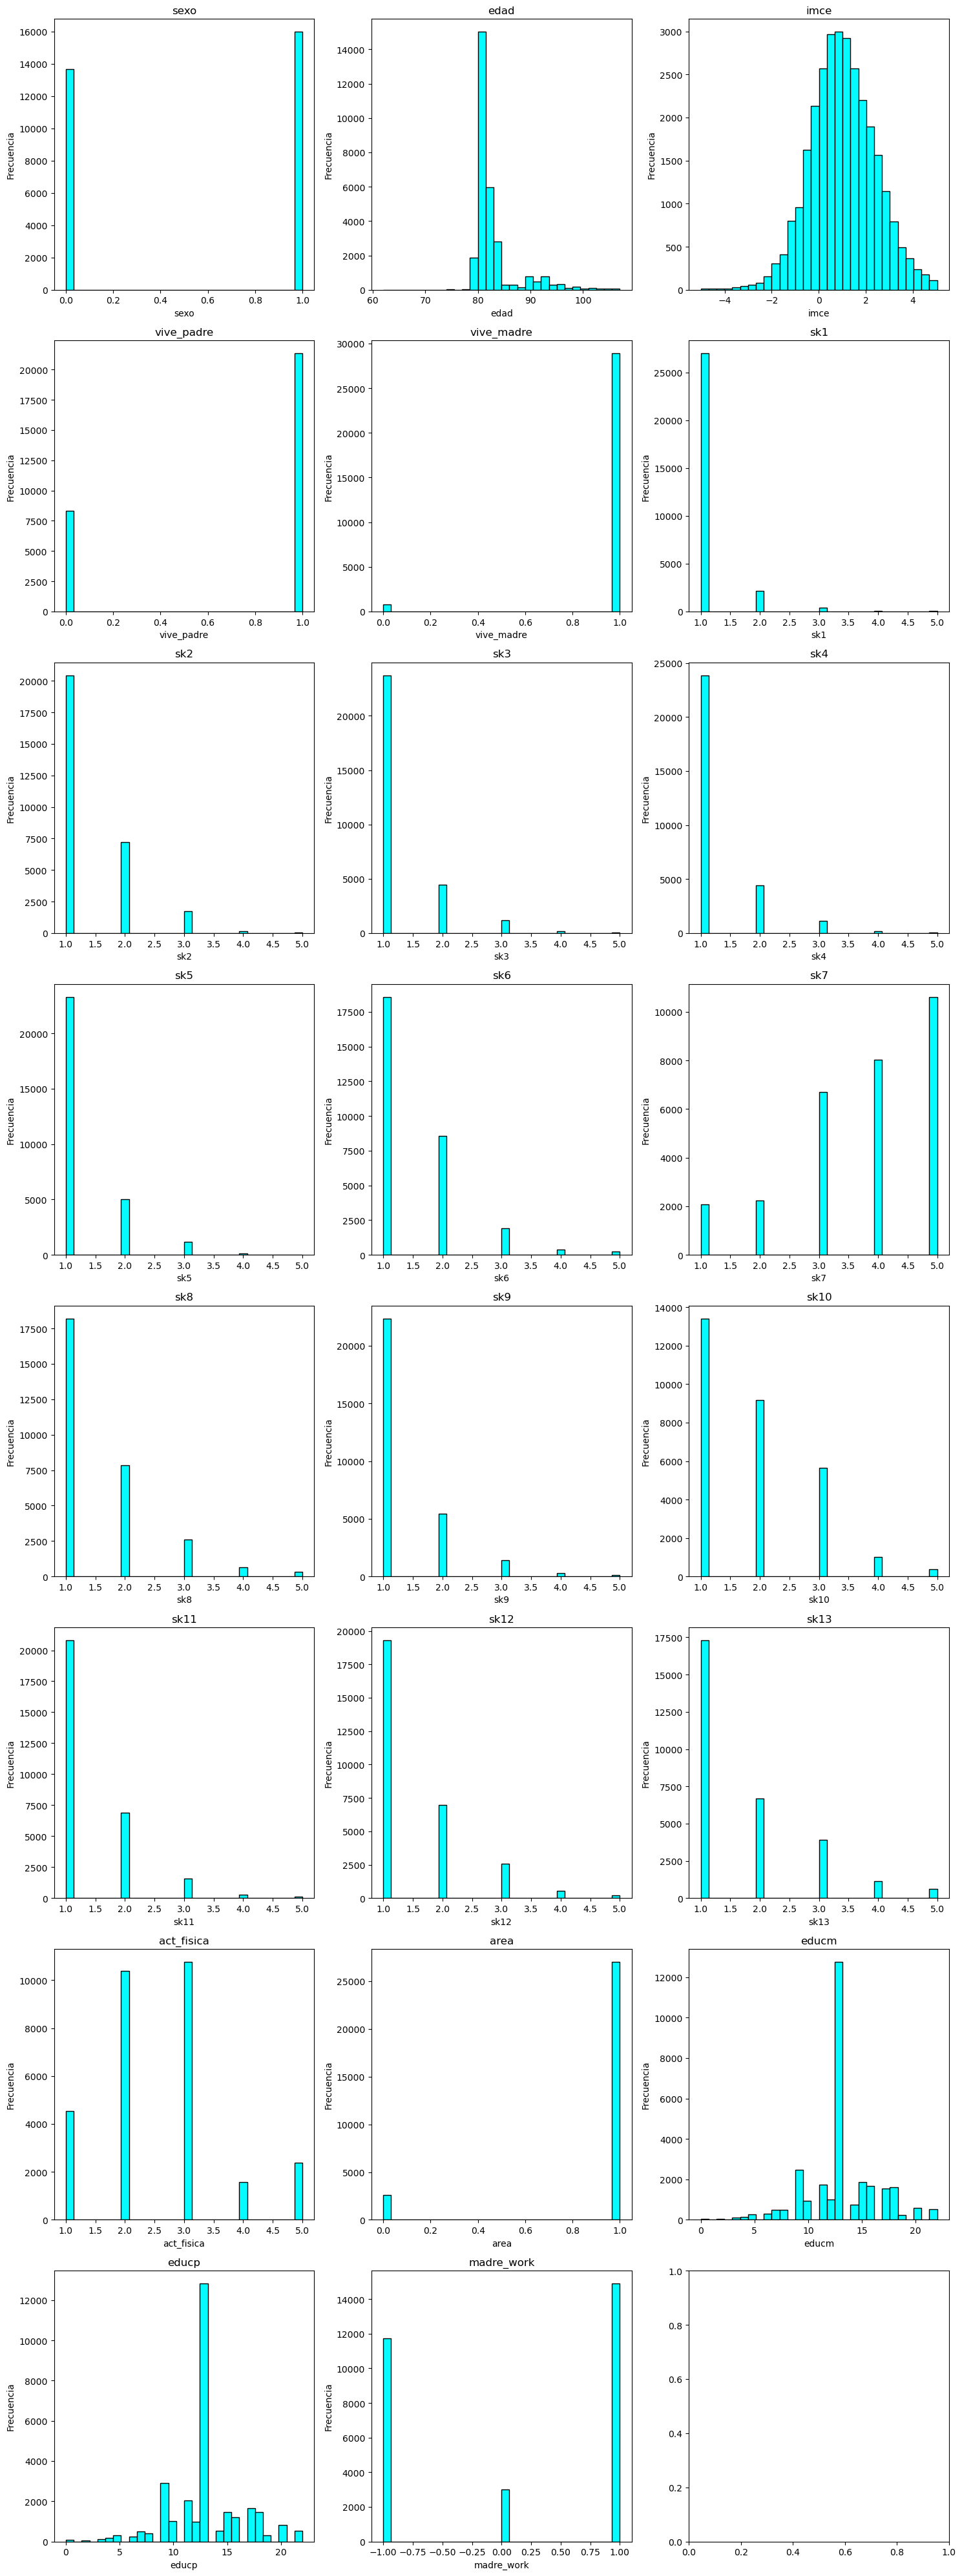

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,...,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000
mean,0.539194,82.545470,1.017501,0.719791,0.974355,1.108419,1.386570,1.256757,1.250852,1.264552,...,1.326303,1.844609,1.378843,1.495596,1.687025,2.556740,0.911625,13.106428,13.002396,0.107036
std,0.498470,4.296714,1.369436,0.449109,0.158078,0.379089,0.643402,0.575516,0.569380,0.558150,...,0.655024,0.933133,0.659927,0.790418,0.979340,1.068159,0.283845,3.328033,3.417926,0.941576
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,1.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,15.000000,1.000000
max,1.000000,107.000000,5.040000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


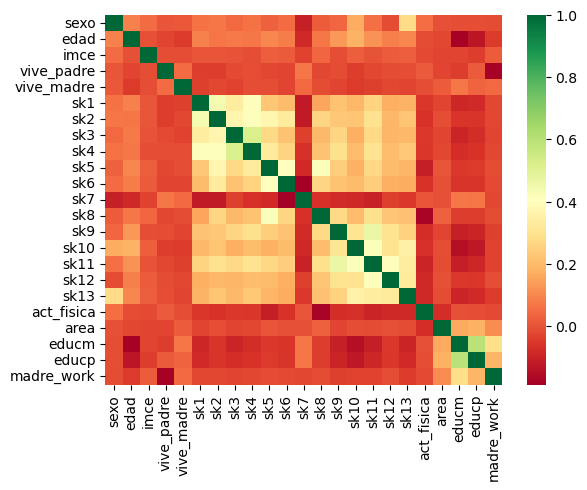

In [61]:

dt=pd.read_csv("../../../data/junaeb3.csv")
indi=0
for i in dt.loc[::,"sk7"]:
    
    
    if i==1:
        dt.loc[indi,"sk7"]=5  
    elif i==2:
        dt.loc[indi,"sk7"]=4
    elif i==3:
        dt.loc[indi,"sk7"]=3
    elif i==4:
        dt.loc[indi,"sk7"]=2
    elif i==5:
        dt.loc[indi,"sk7"]=1
    indi+=1      
dt=dt[dt["vive_madre"]!=2]
dt=dt[dt["vive_padre"]!=2]
dt.dropna(inplace=True)
dt.info()


numerical_columns = dt.select_dtypes(include='number').columns;
num_columns = len(numerical_columns);
fig, axs = plt.subplots((num_columns + 2) // 3, 3, figsize=(15, (num_columns + 2) // 3 * 5));
for i, column in enumerate(numerical_columns):
    ax = axs[i // 3, i % 3];
    ax.hist(dt[column], bins=30, color="#05FBFF", edgecolor='black');
    ax.set_title(f'{column}');
    ax.set_xlabel(column);
    ax.set_ylabel('Frecuencia');
plt.tight_layout();
plt.show()
sns.heatmap(dt.corr(), cmap='RdYlGn');

dt.describe()


2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

R:Podemos apreciar que el programa consideró óptimo utilizar tres factores, de lo cual inferimos que sk7 no es informativa para ninguno de los tres, además la varianza total acumulada nos da un 0.362162 o sea, los factores explican un 36.8% de las variables.

[[0.170956 0.541000 0.150807]
 [0.173792 0.512760 0.354520]
 [0.179809 0.587227 0.162152]
 [0.195005 0.685408 0.194815]
 [0.121379 0.214461 0.716558]
 [0.163073 0.203981 0.486387]
 [-0.070645 -0.074728 -0.146490]
 [0.269462 0.097361 0.478533]
 [0.496403 0.205356 0.201783]
 [0.555717 0.120762 0.127795]
 [0.665475 0.206294 0.202347]
 [0.524699 0.109824 0.141209]
 [0.480038 0.150919 0.132026]]
(array([4.034214, 1.352109, 1.114244, 1.000843, 0.791244, 0.706343,
       0.701189, 0.690190, 0.608368, 0.529874, 0.517230, 0.491686,
       0.462466]), array([3.438924, 0.747141, 0.522044, 0.216095, 0.117614, 0.062805,
       0.007217, -0.011140, -0.034171, -0.063444, -0.081942, -0.084678,
       -0.128355]))
[0.344650 0.418811 0.403460 0.545763 0.574182 0.304773 0.032034 0.311083
 0.329303 0.339736 0.526358 0.307311 0.270644]


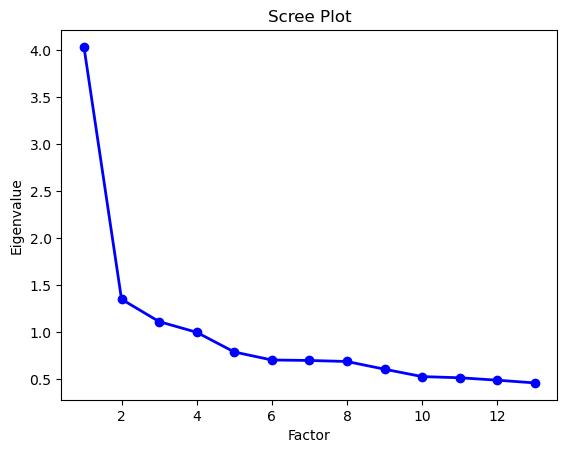

(array([1.752553, 1.607039, 1.348517]), array([0.134812, 0.123618, 0.103732]), array([0.134812, 0.258430, 0.362162]))


In [62]:
dt2=dt[["sk1","sk2","sk3","sk4","sk5","sk6","sk7","sk8","sk9","sk10","sk11","sk12","sk13"]]
fa = FactorAnalyzer(rotation='varimax').fit(dt2)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
print(fa.loadings_)
print(fa.get_eigenvalues())
print(fa.get_communalities())
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()
print(fa.get_factor_variance())





In [63]:
semopy.efa.explore_cfa_model(dt2, pval=0.05)

'eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4\neta2 =~ sk6 + sk7\neta3 =~ sk4 + sk11 + sk2 + sk5 + sk3 + sk9 + sk1 + sk8 + sk13\n'

3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

R: Podemos ver que no hay influencias de las variables sobre los factores

In [64]:

fa.loadings_

dt["eta1"]=dt["sk11"]+dt["sk9"]+dt["sk10"]+dt["sk1"]+dt["sk13"]+ dt["sk4"]
dt["eta2"]=dt["sk7"]+dt["sk6"]
dt["eta3"]=dt["sk4"]+dt["sk11"]+dt["sk2"]+dt["sk5"]+dt["sk3"]+dt["sk9"]+dt["sk1"]+dt["sk8"]+dt["sk13"]

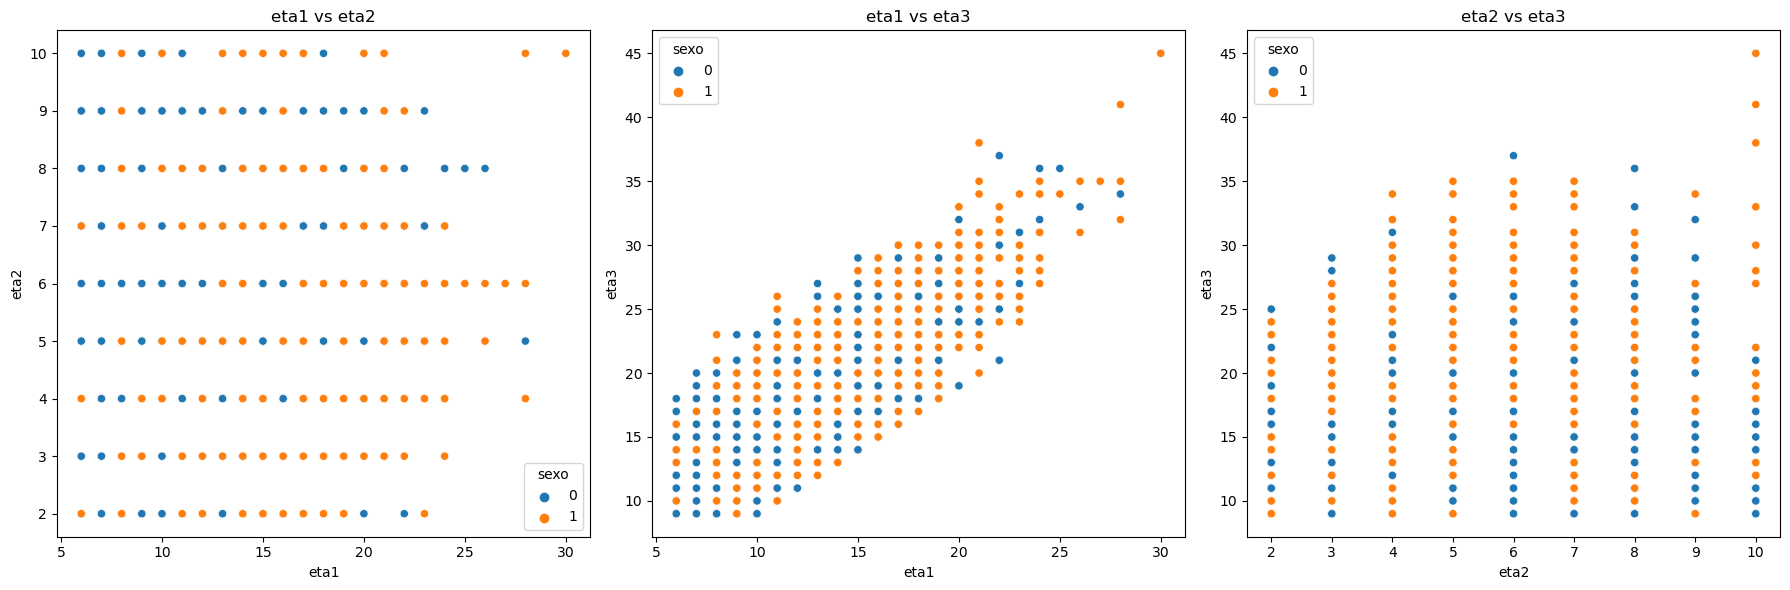

In [65]:


d = "sexo";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar eta1 vs eta2
sns.scatterplot(data=dt, x='eta1', y='eta2', hue=d, ax=axs[0]);
axs[0].set_title('eta1 vs eta2');
axs[0].set_xlabel('eta1');
axs[0].set_ylabel('eta2');

#Graficar eta1 vs eta3
sns.scatterplot(data=dt, x='eta1', y='eta3', hue=d, ax=axs[1]);
axs[1].set_title('eta1 vs eta3');
axs[1].set_xlabel('eta1');
axs[1].set_ylabel('eta3');

#Graficar eta2 vs eta3
sns.scatterplot(data=dt, x='eta2', y='eta3', hue=d, ax=axs[2]);
axs[2].set_title('eta2 vs eta3');
axs[2].set_xlabel('eta2');
axs[2].set_ylabel('eta3');

plt.tight_layout();
plt.show()

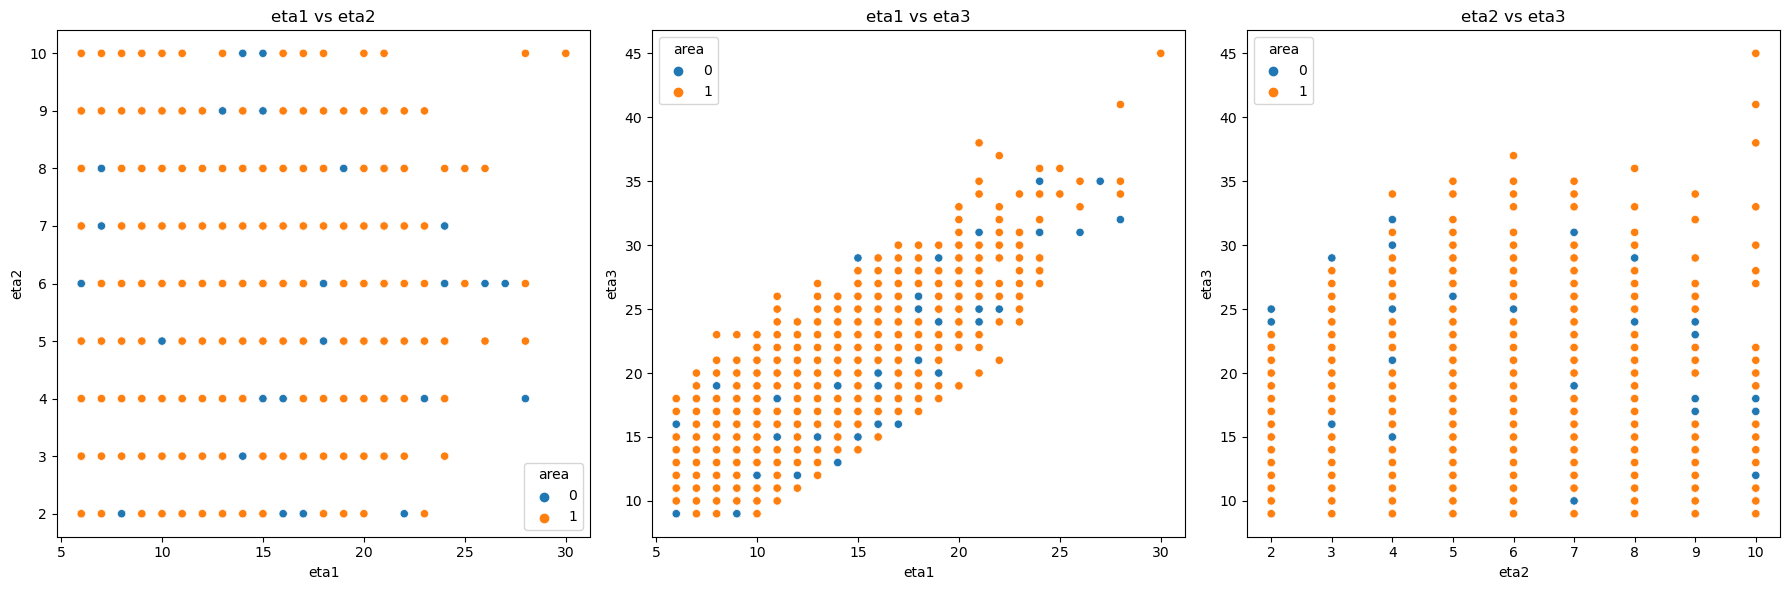

In [66]:

d = "area";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar eta1 vs eta2
sns.scatterplot(data=dt, x='eta1', y='eta2', hue=d, ax=axs[0]);
axs[0].set_title('eta1 vs eta2');
axs[0].set_xlabel('eta1');
axs[0].set_ylabel('eta2');

#Graficar eta1 vs eta3
sns.scatterplot(data=dt, x='eta1', y='eta3', hue=d, ax=axs[1]);
axs[1].set_title('eta1 vs eta3');
axs[1].set_xlabel('eta1');
axs[1].set_ylabel('eta3');

#Graficar eta2 vs eta3
sns.scatterplot(data=dt, x='eta2', y='eta3', hue=d, ax=axs[2]);
axs[2].set_title('eta2 vs eta3');
axs[2].set_xlabel('eta2');
axs[2].set_ylabel('eta3');

plt.tight_layout();
plt.show()

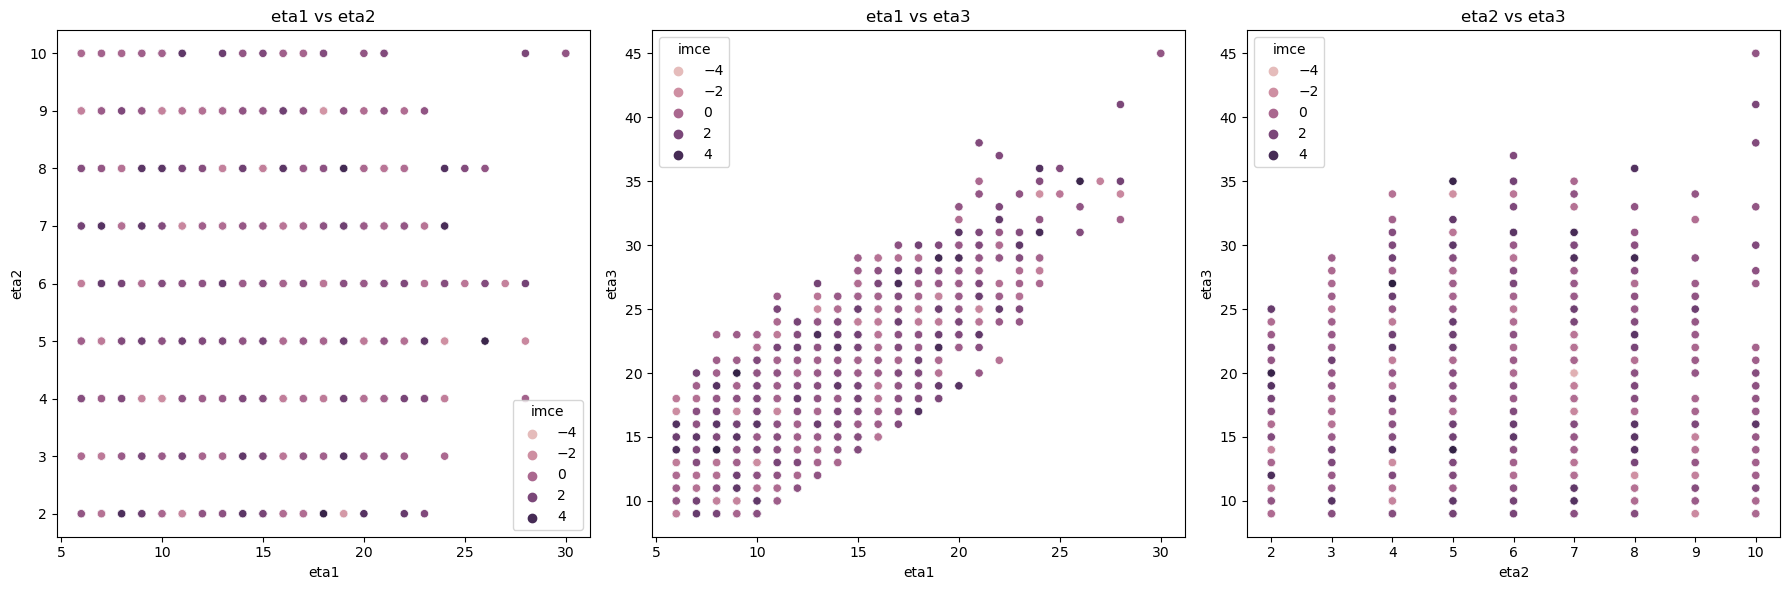

In [67]:

d = "imce";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar eta1 vs eta2
sns.scatterplot(data=dt, x='eta1', y='eta2', hue=d, ax=axs[0]);
axs[0].set_title('eta1 vs eta2');
axs[0].set_xlabel('eta1');
axs[0].set_ylabel('eta2');

#Graficar eta1 vs eta3
sns.scatterplot(data=dt, x='eta1', y='eta3', hue=d, ax=axs[1]);
axs[1].set_title('eta1 vs eta3');
axs[1].set_xlabel('eta1');
axs[1].set_ylabel('eta3');

#Graficar eta2 vs eta3
sns.scatterplot(data=dt, x='eta2', y='eta3', hue=d, ax=axs[2]);
axs[2].set_title('eta2 vs eta3');
axs[2].set_xlabel('eta2');
axs[2].set_ylabel('eta3');

plt.tight_layout();
plt.show()

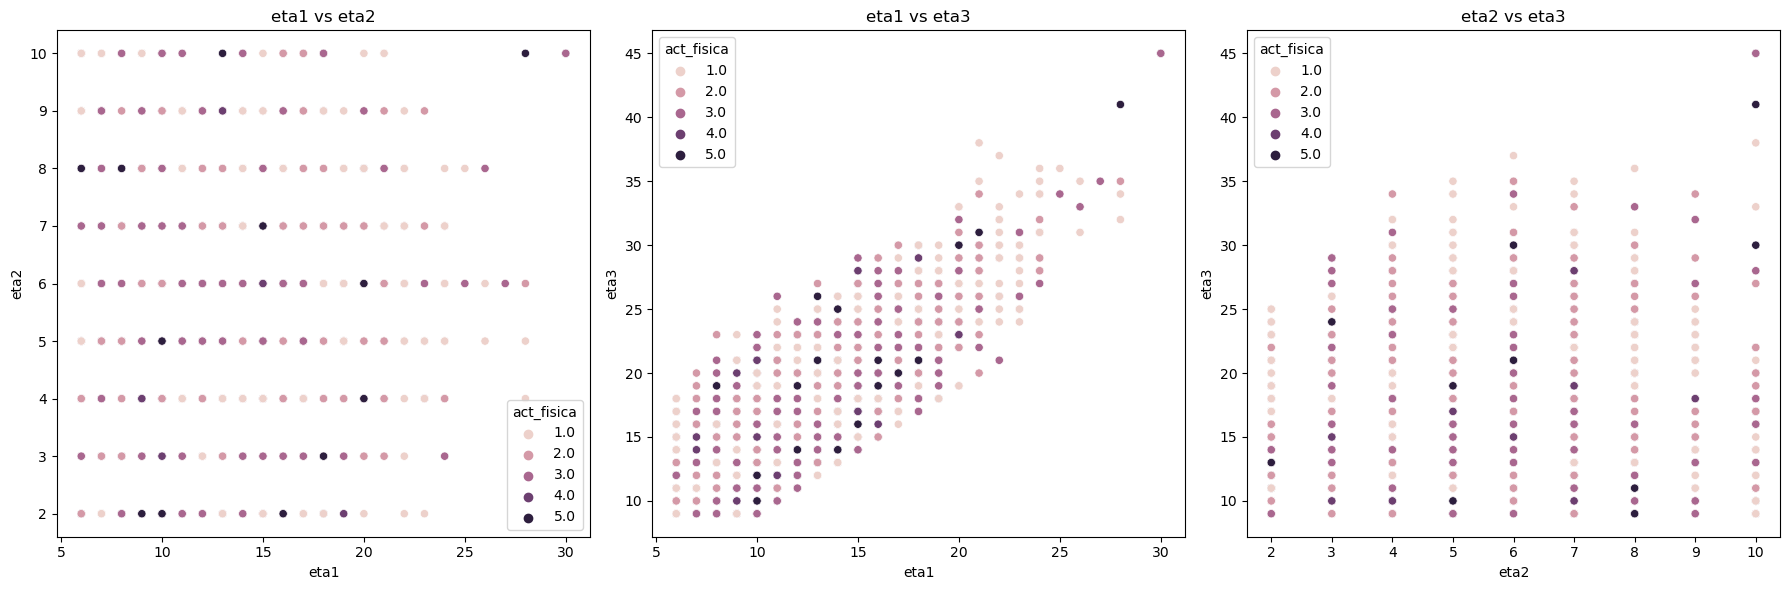

In [68]:

d = "act_fisica";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar eta1 vs eta2
sns.scatterplot(data=dt, x='eta1', y='eta2', hue=d, ax=axs[0]);
axs[0].set_title('eta1 vs eta2');
axs[0].set_xlabel('eta1');
axs[0].set_ylabel('eta2');

#Graficar eta1 vs eta3
sns.scatterplot(data=dt, x='eta1', y='eta3', hue=d, ax=axs[1]);
axs[1].set_title('eta1 vs eta3');
axs[1].set_xlabel('eta1');
axs[1].set_ylabel('eta3');

#Graficar eta2 vs eta3
sns.scatterplot(data=dt, x='eta2', y='eta3', hue=d, ax=axs[2]);
axs[2].set_title('eta2 vs eta3');
axs[2].set_xlabel('eta2');
axs[2].set_ylabel('eta3');

plt.tight_layout();
plt.show()

4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

R: A eta 1 le reconoceremos como curiosidad, a eta 2 amable y 3 expresivo 

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.468
Number of iterations: 34
Params: 0.832 1.086 0.888 1.054 0.651 -0.520 0.803 0.734 0.471 0.976 0.214 0.127 0.322 0.173 0.147 0.159 0.105 0.618 0.222 0.456 0.721 0.241 0.238 0.233 0.200 0.218 1.376 0.520 0.281
    lval  op  rval  Estimate  Est. Std  Std. Err     z-value p-value
0   sk11   ~  eta1  1.000000  0.701129         -           -       -
1    sk9   ~  eta1  0.831654  0.587625  0.009907   83.944368     0.0
2   sk10   ~  eta1  1.085706  0.538524  0.013939   77.889778     0.0
3   sk12   ~  eta1  0.887905  0.519927  0.011758   75.513147     0.0
4   sk13   ~  eta1  1.054458  0.498338  0.014503    72.70543     0.0
5    sk4   ~  eta1  0.650931  0.529109  0.008488   76.691705     0.0
6    sk6   ~  eta2  1.000000  0.772545         -           -       -
7    sk7   ~  eta2 -0.520134 -0.244057  0.021245  -24.482629     0.0
8    sk2   ~  eta3  1.000000  0.6462

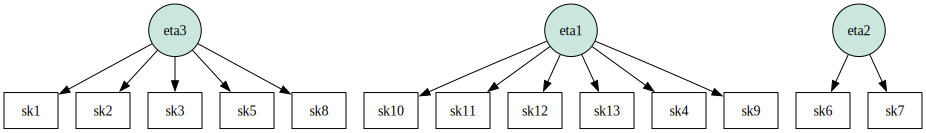

In [69]:
mod = """
# measurement model
eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4 # Curioso
eta2 =~ sk6 + sk7                             # Amable
eta3 =~ sk2 + sk5 + sk3  + sk1 + sk8          # Expresivo
    """

model = semopy.Model(mod)
out=model.fit(dt2)
print(out)
print(model.inspect(mode='list', what="names", std_est=True))
print(semopy.calc_stats(model))
semopy.semplot(mod, "semmodel.png")

5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?



R: Luego del proceso, se concluyó que el número de clases latentes óptimo es de 3, dado que tenemos valores muy buenos como entropia de 0.9819.

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.96s/it, max_LL=-4.58e+5, max_avg_LL=-15.4]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.69s/it, max_LL=-4.55e+5, max_avg_LL=-15.4]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.97s/it, max_LL=-8.99e+4, max_avg_LL=-3.03]


MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances sk1             0.0000  0.2374  0.6525
                      sk10            0.7468  0.5945  1.2285
                      sk11            0.2545  0.2830  1.0359
                      sk12            0.4832  0.4147  1.2615
                      sk13            0.7821  0.6615  1.5917
                      sk2             0.2163  0.3904  0.8748
                      sk3             0.0699  0.5336  0.9075
                      sk4             0.0000  0.2871  0.8836
                      sk5             0.1640  0.2436  0.8356
                      sk6             0.4060  0.3634  1.0460
                      sk7             1.4528  1.3014  1.5674
                      sk8             0.5614  0.3940  1.1679
                      sk9             0

Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.14s/it, max_LL=-1.44e+6, max_avg_LL=-48.5]


MODEL REPORT
    Measurement model parameters
          model_name       gaussian_unit                  
          class_no                     0        1        2
          param variable                                  
          means act_fisica        2.6245   2.5419   2.3298
                area              0.9219   0.8802   0.8924
                edad             81.1721  93.5577  81.4847
                educm            13.7230  11.1842  11.9853
                educp            13.5547  11.4817  11.8921
                eta1              7.4153   9.6170  12.1491
                eta2              5.2246   5.0532   5.4699
                eta3             10.6658  13.1407  17.0690
                imce              1.0080   1.0065   1.0563
                madre_work        0.1622  -0.0356  -0.0089
                sexo              0.4934   0.6570   0.6357
                sk1               1.0277   1.1647   1.3583
                sk10              1.5897   2.2604   2.5082
          

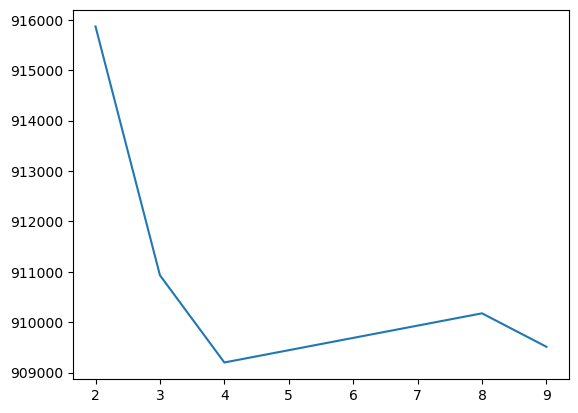

In [70]:
K = range(2, 10)
fits = []
BIC = []

for k in K:
    
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(dt2)
    

    fits.append(model)
    
   
    BIC.append(model.sabic(dt2))

sns.lineplot(x = K, y = BIC)  

df=pd.read_csv('../../../data/junaeb3.csv')
df1=dt.copy()
model = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123).fit(dt2)


model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

model.fit(df1)
df1['pred']=model.predict(df1)



<Axes: xlabel='sk11', ylabel='sk2'>

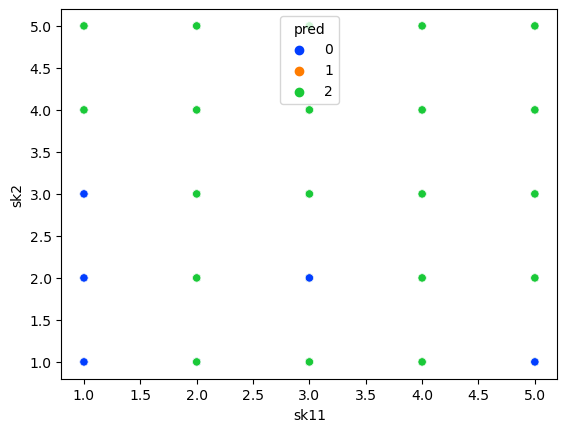

In [71]:


df1.groupby(['pred'])[['sk11','sk6','sk2']].mean()

sns.scatterplot(data=df1, x='sk11', y='sk2', hue='pred', palette="bright")


<Axes: xlabel='sk6', ylabel='sk2'>

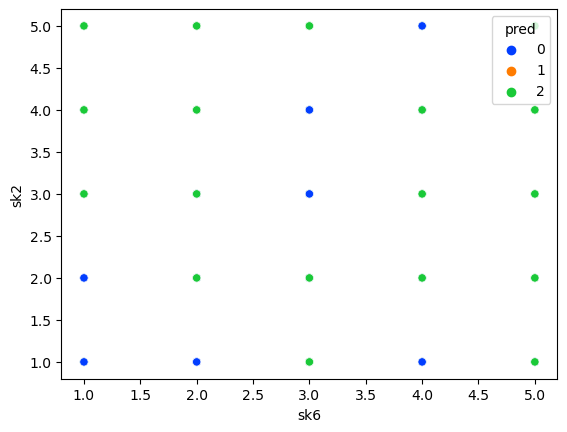

In [72]:
sns.scatterplot(data=df1, x='sk6', y='sk2', hue='pred', palette="bright")


<Axes: xlabel='sk11', ylabel='sk6'>

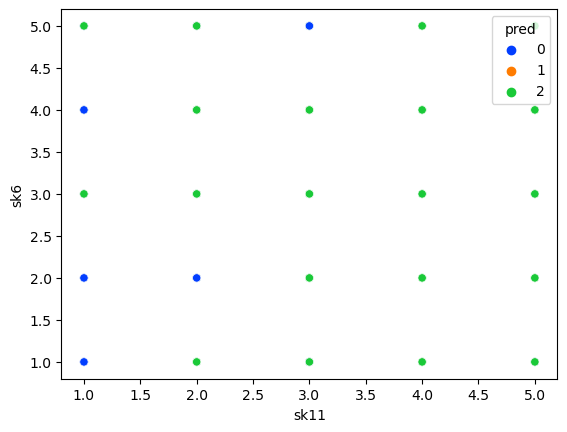

In [73]:
sns.scatterplot(data=df1, x='sk11', y='sk6', hue='pred', palette="bright")

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

R: Luego de realizar hartas pruebas con distintas variables llegamos a la conclusión, que según criterios de BIC, TLI, CLI y RMSEA sería bueno agregar que el imce también se ve afectado por la actividad fisica, si la madre trabaja o no, si vive con la madre, vive con el padre y la edad del niño, por mencionar algunos parametros de confirmación, se desea que el TLI sea de 0.9 y el RMSEA de 0.05, nuestros valores nos dieron 0.842176 y 0.054834 respectivamente, lo cual tambiém es bueno y cumple los mínimos requeridos, la explicación es que vivir con el padre o madre y que esta última no trabaje, puede influir en que el niño estará más tiempo con uno de sus padres, lo que puede llevar a tener una alimentación más ordenada, basada en lo que le ofrece directamente el adulto, respecto a la actividad física se tiene una relación directa, pues una persona activa en este sentido tenderá a estar en forma, finalmente la edad es otro factor que, pues dependiendo de la etapa de la niñez se puede tender a una alimentación menos completa.

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.566
Number of iterations: 57
Params: 0.833 1.091 0.889 1.056 0.649 -0.533 0.808 0.737 0.474 0.992 1.156 -0.477 -0.110 -0.023 -0.067 2.051 1.112 17.927 0.087 0.314 0.134 0.001 0.127 0.885 0.105 0.616 0.222 0.456 0.720 0.243 0.239 0.234 0.200 0.226 1.374 0.517 0.281 0.025 0.201
       DoF  DoF Baseline          chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  132           153  16774.641348           0.0   86533.351867  0.807333   

            GFI      AGFI       NFI       TLI     RMSEA        AIC        BIC  \
Value  0.806148  0.775308  0.806148  0.776681  0.065227  76.867917  400.43966   

         LogLik  
Value  0.566042  


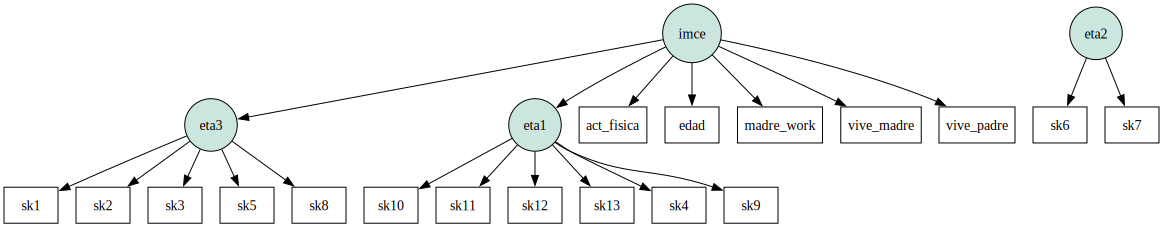

In [74]:
mod_com = """
# measurement model
eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13+ sk4 
eta2 =~ sk6 + sk7
eta3 =~  sk2 + sk5 + sk3 + sk1 + sk8
imce =~ eta1 + eta3 + act_fisica + madre_work + vive_madre + vive_padre+edad


    """

model_cfa = semopy.Model(mod_com);
out = model_cfa.fit(dt);
print(out)
model_cfa.inspect(mode='list', what="names", std_est=True)
print(semopy.calc_stats(model_cfa))
semopy.semplot(mod_com, "semmodel.png")

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

R: Si existen diferencias significativas, al estimar el modelo en general los parametros son mejores, al separar las clases tenemos que para la primera el RMSEA mejoró bastante pasando a un 0.4, pero el TLI  empeoró a niveles no recomendables, para el caso dos ambos parametros empeoraron un poco, pero se siguen manteniendo en buenos niveles, finalmente en la clase 3 empeoraron ambos, 0.61 y 0.06 siendo valores no recomendados, puede ser que el modelo sea más adecuado para la clase 2.

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.251
Number of iterations: 79
Params: 0.528 1.538 1.371 0.766 0.121 -0.486 1.034 0.325 0.124 1.358 3.226 -2.333 0.772 -0.013 -0.542 -0.016 1.104 2.029 0.040 0.267 0.016 0.003 0.003 0.877 0.030 0.483 0.118 0.327 0.464 0.188 0.135 0.109 0.102 0.126 1.370 0.365 0.136 0.020 0.196
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline      CFI  \
Value  132           153  5152.309322           0.0   14932.970009  0.66033   

            GFI     AGFI       NFI       TLI     RMSEA        AIC         BIC  \
Value  0.654971  0.60008  0.654971  0.606292  0.043006  77.498924  386.821414   

         LogLik  
Value  0.250538  


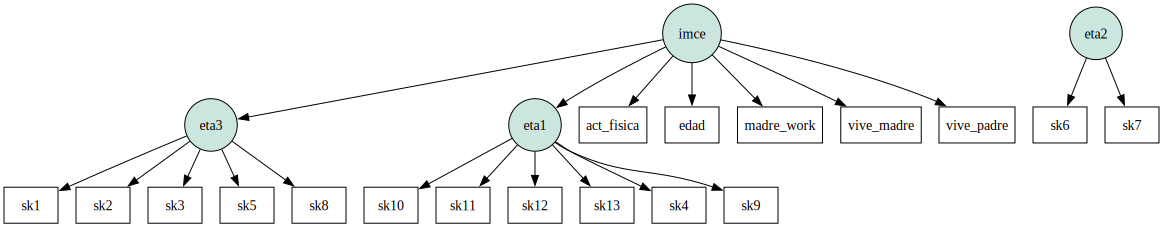

In [75]:

mod_coms = """
# measurement model
eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4
eta2 =~ sk6 + sk7
eta3 =~  sk2 + sk5 + sk3 + sk1 + sk8
imce =~ eta1 + eta3 + act_fisica + madre_work + vive_madre + vive_padre+edad


    """

dfclass1=df1[df1["pred"]==0]
dfclass2=df1[df1["pred"]==1]
dfclass3=df1[df1["pred"]==2]


model_cfa = semopy.Model(mod_com);
out = model_cfa.fit(dfclass1);
print(out)
model_cfa.inspect(mode='list', what="names", std_est=True)
print(semopy.calc_stats(model_cfa))
semopy.semplot(mod_com, "semmodel.png")







Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.662
Number of iterations: 53
Params: 0.818 0.937 0.938 1.002 0.587 -0.417 0.923 0.670 0.476 0.998 1.178 -0.428 -0.004 -0.021 -0.002 2.134 1.198 16.429 0.133 0.400 0.188 0.001 0.155 0.864 0.184 0.913 0.322 0.582 0.932 0.278 0.327 0.299 0.287 0.327 1.557 0.594 0.472 0.045 0.215
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  132           153  2078.966005           0.0    8930.992494  0.778199   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.767219  0.730186  0.767219  0.742913  0.068548  76.675818   

              BIC    LogLik  
Value  312.702963  0.662091  


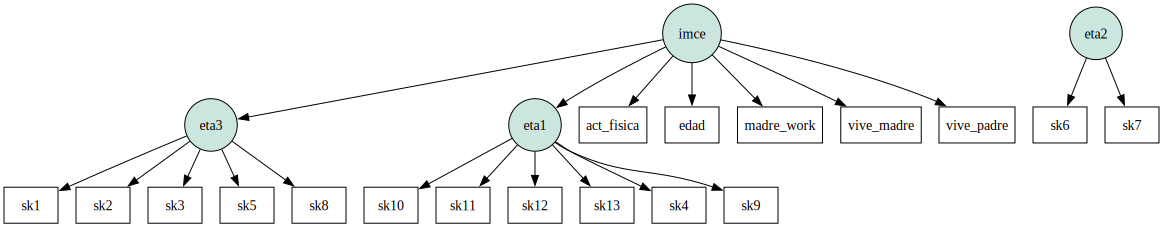

In [76]:

model_cfa = semopy.Model(mod_com);
out = model_cfa.fit(dfclass2);
print(out)
model_cfa.inspect(mode='list', what="names", std_est=True)
print(semopy.calc_stats(model_cfa))
semopy.semplot(mod_com, "semmodel.png")


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.864
Number of iterations: 48
Params: 0.703 0.765 0.747 0.280 0.266 -0.547 0.630 0.631 0.642 0.373 1.780 -0.419 0.217 -0.050 -0.167 2.710 1.078 3.876 0.252 0.283 0.103 0.117 0.057 0.886 0.279 0.769 0.411 0.739 1.270 0.379 0.562 0.664 0.466 0.434 1.272 0.929 0.658 0.031 0.209
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  132           153  5125.783511           0.0    10951.78263  0.537561   

            GFI      AGFI       NFI       TLI    RMSEA        AIC         BIC  \
Value  0.531968  0.457508  0.531968  0.463991  0.07988  76.271237  337.094637   

         LogLik  
Value  0.864382  


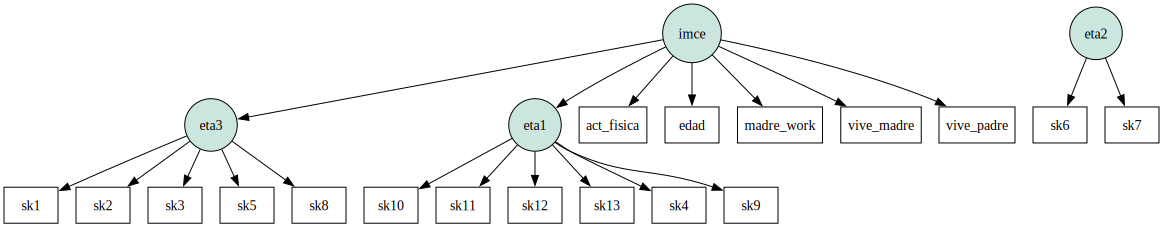

In [77]:

model_cfa = semopy.Model(mod_com);
out = model_cfa.fit(dfclass3);
print(out)
model_cfa.inspect(mode='list', what="names", std_est=True)
print(semopy.calc_stats(model_cfa))
semopy.semplot(mod_com, "semmodel.png")